In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_BINARY_CLASS_4L.csv')

C:\Users\asus\AppData\Local\Temp\ipykernel_34752\4235449716.py:1: DtypeWarning: Columns (84) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_BINARY_CLASS_4L.csv')


In [3]:
train_df.columns.values.tolist()

['Flow ID',
 'Source IP',
 'Source Port',
 'Destination IP',
 'Destination Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag 

In [4]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

for col in train_df.select_dtypes(include=['object', 'category']).columns:
    train_df[col] = LabelEncoder().fit_transform(train_df[col].astype(str))

In [5]:
train_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,351993,201,59099,24,80,6,45460,110861755,26,26,...,64223.338986,392446.0,179351.0,9.863210e+06,413171.813769,10007500.0,8632089.0,165,0,0
1,357314,201,59102,519,443,6,45464,40335006,9,10,...,43.554563,90287.0,90185.0,9.993447e+06,40495.753715,10018634.0,9933709.0,0,0,0
2,335244,197,0,277,0,0,45486,113244633,56,0,...,859690.585416,2978061.0,4.0,9.188876e+06,809901.667647,9882838.0,6781893.0,0,0,0
3,352273,201,59155,280,80,6,45526,95628949,21,20,...,177.422362,15367.0,14798.0,1.001418e+07,5184.077926,10016037.0,10000366.0,0,0,0
4,331567,201,59131,53,80,6,45527,95613243,21,20,...,17.902514,26534.0,26473.0,1.000431e+07,21.430119,10004365.0,10004289.0,0,0,0


In [6]:
# valid_df.head()

In [7]:
# standard deviation 12 features
train_df.drop(columns=['Bwd PSH Flags','Fwd URG Flags','Bwd URG Flags','FIN Flag Count',
                    'PSH Flag Count','ECE Flag Count','Fwd Avg Bytes/Bulk','Fwd Avg Packets/Bulk',
                    'Fwd Avg Bulk Rate','Bwd Avg Bytes/Bulk','Bwd Avg Packets/Bulk','Bwd Avg Bulk Rate'], inplace=True)

In [8]:
train_df.shape

(399998, 75)

In [9]:
# correlation 8 features
train_df.drop(columns=['Subflow Fwd Packets','Subflow Bwd Packets','Subflow Fwd Bytes','Subflow Bwd Bytes',
                     'Avg Fwd Segment Size','RST Flag Count','Avg Bwd Segment Size','Fwd Header Length.1'], inplace=True)

In [10]:
train_df.shape

(399998, 67)

In [11]:
# train_df.drop(columns=['Flow ID','Source IP','Source Port','Destination IP','Destination Port','Protocol','Timestamp','SimillarHTTP'],inplace=True)

In [12]:
# train_df.shape

In [13]:
# Assuming target column is named 'target'
X_train = train_df[['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size',
                    'Init_Win_bytes_backward','Max Packet Length','Min Packet Length','min_seg_size_forward',
                    'Flow Packets/s','Inbound','Flow Duration','Fwd PSH Flags','Flow IAT Min','Fwd IAT Total',
                    'Fwd IAT Max','CWE Flag Count','Bwd IAT Std','Idle Mean','Active Max','Fwd Packets/s',
                    'SYN Flag Count','Bwd IAT Min','Fwd IAT Mean']]
y_train = train_df['Label']


In [14]:
import time

start = time.time()
clf = RandomForestClassifier()
print(start)
clf.fit(X_train, y_train)

end = time.time()

elapsed = end - start
print(f"Elapsed time for TR: {elapsed:.4f} seconds")

1761660179.0044897
Elapsed time for TR: 32.1559 seconds


In [15]:
start = time.time()

explainer = shap.TreeExplainer(clf)
print(start)
shap_values = explainer.shap_values(X_train)  # For binary: shap_values[1] for class 1

end = time.time()

elapsed = end - start
print(f"Elapsed time for TS: {elapsed:.4f} seconds")

1761660211.1670785
Elapsed time for TS: 6600.5812 seconds


In [16]:
print("SHAP values shape:", np.array(shap_values[1]).shape)
print("X_train shape:", X_train.shape)

SHAP values shape: (23, 2)
X_train shape: (399998, 23)


In [17]:
# Check correct SHAP shape
print(shap_values.shape)  # Should be (n_samples, n_features)
print(X_train.shape)         # Should match


(399998, 23, 2)
(399998, 23)


In [24]:
shap_values_class1 = shap_values[:, :, 0]

shap_importance = (shap_values_class1).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': X_train.columns,
    'shap_importance': shap_importance
}).sort_values(by='shap_importance', ascending=False)

shap_df.to_csv("23F_SHAP_feature_importance.csv", index=False)

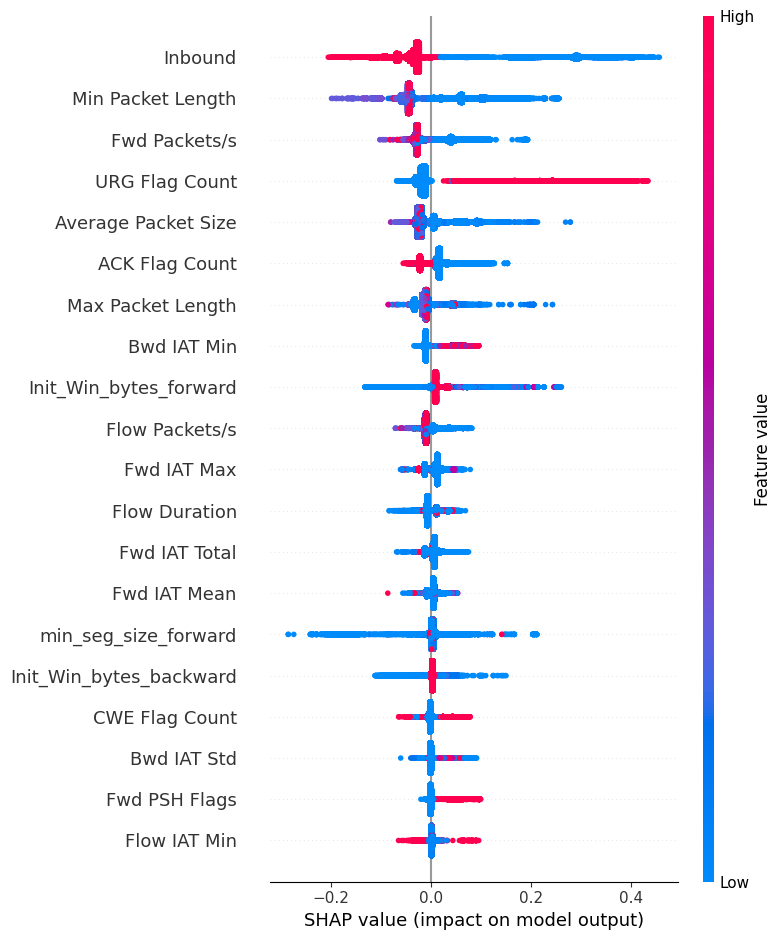

TypeError: `save_html` requires a Visualizer returned by `shap.plots.force()`.

In [34]:
shap_values_class1 = shap_values[:, :, 0]
# Now plot
shap.summary_plot(shap_values_class1, X_train)
plt.savefig('23_shap_summary_plot.png', bbox_inches='tight', dpi=300)
# shap.save_html("23_shap_summary_plot.html", summary_plot)
plt.show()

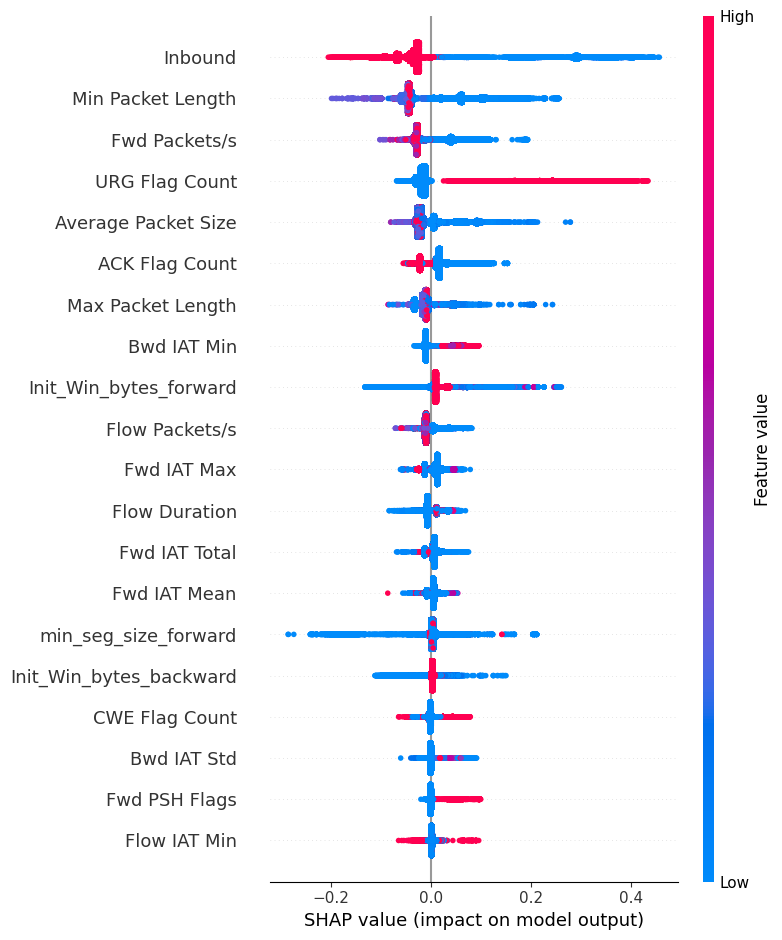

<Figure size 640x480 with 0 Axes>

In [35]:
summary_plot = shap.summary_plot(shap_values_class1, X_train)
plt.savefig('23_shap_summary_plot.png', bbox_inches='tight', dpi=300)
# shap.save_html("23_shap_summary_plot.html", summary_plot)
plt.show()

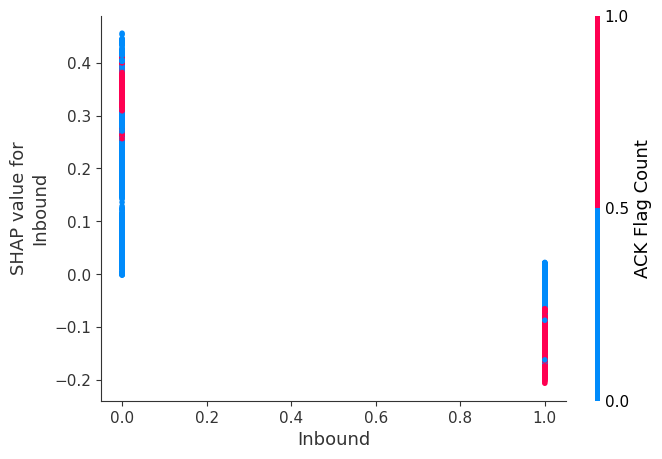

In [38]:
# 2. Dependence Plot
shap.dependence_plot('Inbound', shap_values_class1, X_train)
# plt.savefig('23_shap_dependence_plot.png', bbox_inches='tight', dpi=300)
# shap.save_html("23_shap_dependence_plot.html", dependence_plot)
# plt.show()

In [33]:
import shap
shap.initjs()
# Then generate your plots, e.g. shap.force_plot(...)

# 3. Force Plot
shap.force_plot(explainer.expected_value[1], shap_values_class1[1], X_train.iloc[0])
# plt.savefig('23_shap_force_plot.png', bbox_inches='tight', dpi=300)

In [31]:
import shap
import time

start = time.time()

shap.initjs()

# Create the force plot
force_plot = shap.force_plot(explainer.expected_value[1], shap_values_class1[1], X_train.iloc[0],matplotlib=False)

# Save to HTML
shap.save_html("23_shap_force_plot.html", force_plot)

end = time.time()
elapsed = end - start
print(f"Elapsed time for TS: {elapsed:.4f} seconds")


Elapsed time for TS: 0.0129 seconds


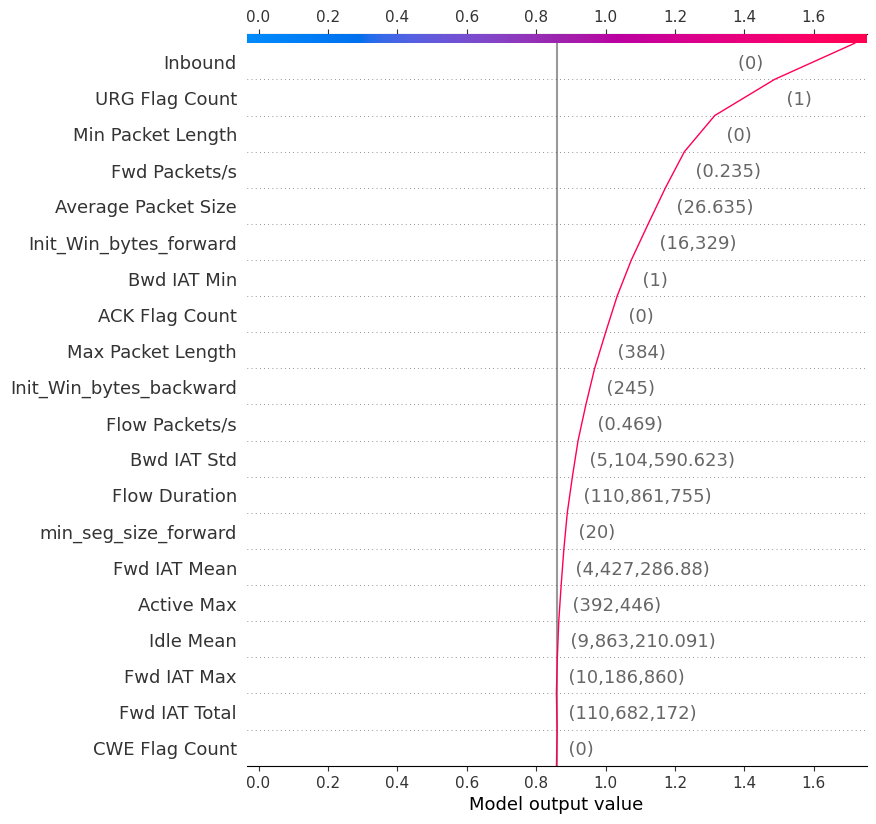

In [36]:
# 4. Decision Plot
shap.decision_plot(explainer.expected_value[1], shap_values_class1[1], X_train)
# plt.savefig('23_shap_decision_plot.png', bbox_inches='tight', dpi=300)
# shap.save_html("23_shap_decision_plot.html", decision_plot)
# plt.show()

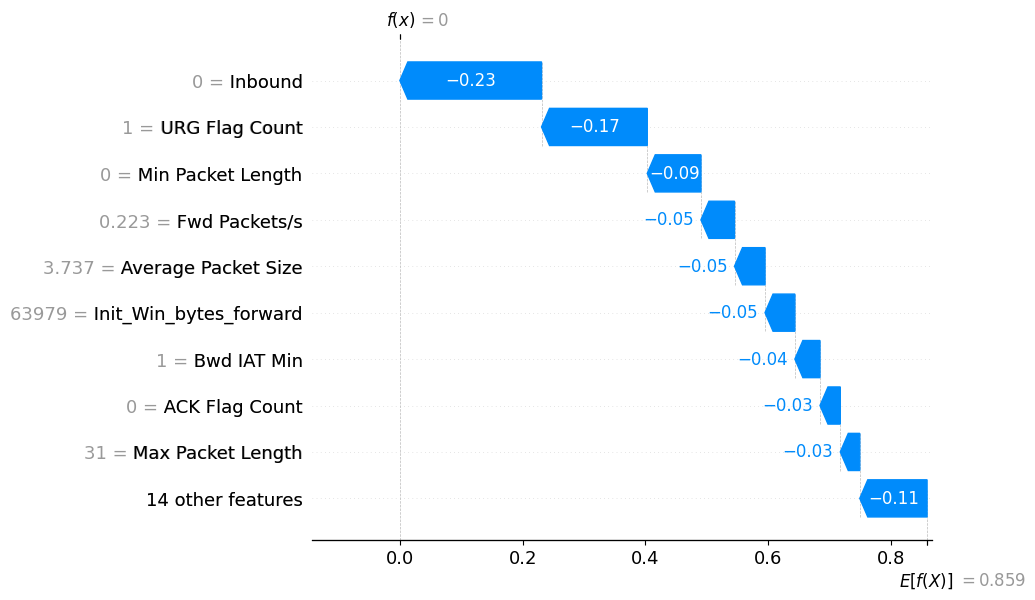

In [37]:
import shap

i = 1  # instance index
shap_value_expl = shap.Explanation(
    values=shap_values[1][:, 1],  # [instance][feature, class]
    base_values=explainer.expected_value[1],
    data=X_train.iloc[1, :].values,
    feature_names=X_train.columns.tolist()
)

shap.plots.waterfall(shap_value_expl)
# plt.savefig('23_shap_waterfall_plot.png', bbox_inches='tight', dpi=300)
# shap.save_html("23_shap_waterfall_plot.html", waterfall_plot)
# plt.show()
